In [1]:
%pwd

'C:\\Users\\Mohit Kedia\\Notebooks\\Refactored_Py_DS_ML_Bootcamp-master\\13-Logistic-Regression'

In [4]:
# Step 1: Import Required Libraries 

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [6]:
# Step 2: Load the Dataset

In [5]:
# Load CSV File

df = pd.read_csv("fraud_transactions.csv")

# Display First 5 Rows
print(df.head())

   transaction_id transaction_type    amount  customer_age customer_gender  \
0            1000         Transfer   2598.57            35            Male   
1            1001         Transfer  21941.93            50            Male   
2            1002         Transfer  75904.86            28          Female   
3            1003       Withdrawal  84764.69            56          Female   
4            1004       Withdrawal  57777.48            63            Male   

   account_balance device_type location merchant_category  transaction_time  \
0        115489.32      Mobile  Chennai       Electronics                18   
1        282816.31     Desktop   Mumbai            Travel                18   
2        173424.01      Mobile   Mumbai           Fashion                 3   
3        404528.50     Desktop  Chennai       Electronics                12   
4         27683.07      Mobile  Kolkata       Electronics                 7   

  international_transaction  fraud  
0                  

In [8]:
# Step 3: Understanding the Dataset

In [9]:
# Shape of Dataset
print(df.shape)

(1000, 12)


In [10]:
# Dataset Information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             1000 non-null   int64  
 1   transaction_type           1000 non-null   object 
 2   amount                     1000 non-null   float64
 3   customer_age               1000 non-null   int64  
 4   customer_gender            1000 non-null   object 
 5   account_balance            1000 non-null   float64
 6   device_type                1000 non-null   object 
 7   location                   1000 non-null   object 
 8   merchant_category          1000 non-null   object 
 9   transaction_time           1000 non-null   int64  
 10  international_transaction  1000 non-null   object 
 11  fraud                      1000 non-null   int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 93.9+ KB
None


In [11]:
# Statistical Summary
print(df.describe())

       transaction_id        amount  customer_age  account_balance  \
count     1000.000000   1000.000000   1000.000000      1000.000000   
mean      1499.500000  48879.750860     44.446000    246140.738890   
std        288.819436  28773.889416     15.189002    138737.664273   
min       1000.000000    407.270000     18.000000      5537.720000   
25%       1249.750000  23997.875000     31.000000    127618.407500   
50%       1499.500000  47477.300000     44.000000    243489.865000   
75%       1749.250000  73825.727500     58.000000    364080.380000   
max       1999.000000  99990.790000     70.000000    499788.350000   

       transaction_time        fraud  
count       1000.000000  1000.000000  
mean          11.686000     0.410000  
std            6.866043     0.492079  
min            0.000000     0.000000  
25%            6.000000     0.000000  
50%           12.000000     0.000000  
75%           18.000000     1.000000  
max           23.000000     1.000000  


In [12]:
# Step 4: Data Cleaning and Preprocessing

In [14]:
# Check Missing Values
print(df.isnull().sum())

transaction_id               0
transaction_type             0
amount                       0
customer_age                 0
customer_gender              0
account_balance              0
device_type                  0
location                     0
merchant_category            0
transaction_time             0
international_transaction    0
fraud                        0
dtype: int64


In [15]:
# Remove Duplicate Records

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
# Check Duplicate Removal

In [18]:
print(df.shape)

(1000, 12)


In [19]:
# Step 5: Exploratory Data Analysis (EDA)

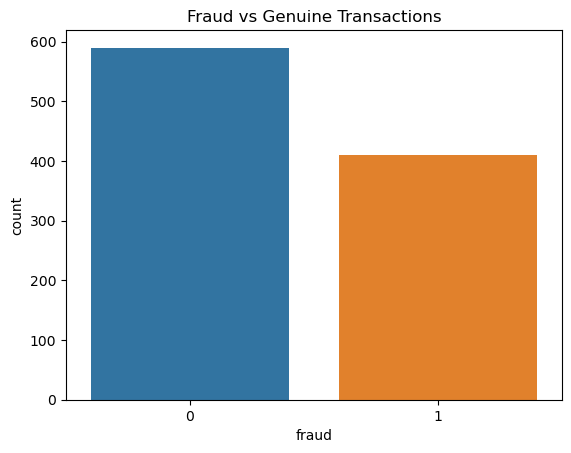

In [22]:
# Fraud vs Genuine Transactions
sns.countplot(x="fraud", data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

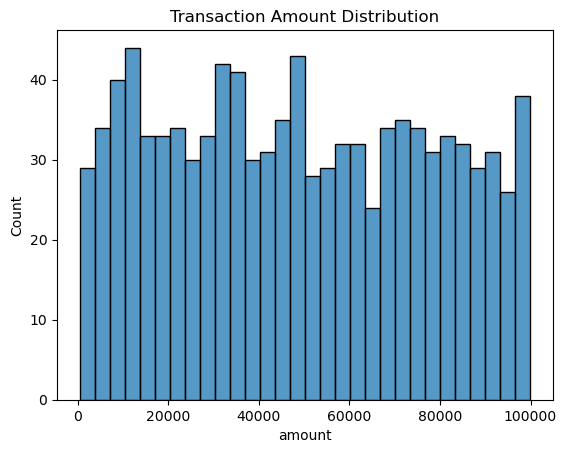

In [23]:
# Transaction Amount Distribution
sns.histplot(df["amount"], bins=30)
plt.title("Transaction Amount Distribution")
plt.show()

C:\Users\Mohit Kedia\AppData\Local\Temp\ipykernel_29236\3620742398.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(),annot=True,cmap='coolwarm')


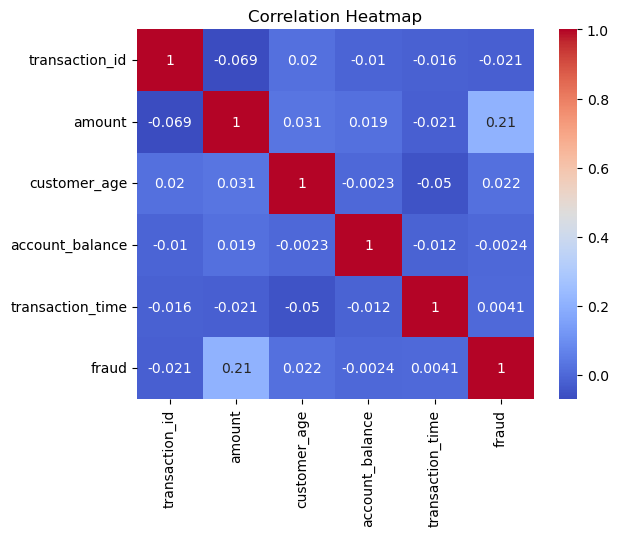

In [25]:
#Correlation Heatmap
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Text(0.5, 1.0, 'Count of different transaction_types')

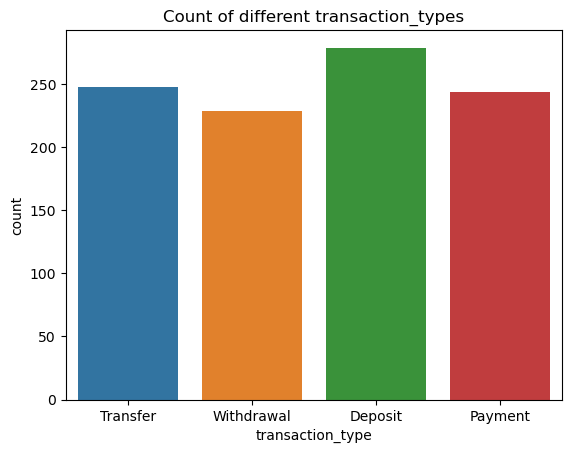

In [26]:
# Transaction type counts
sns.countplot(x='transaction_type',data=df)
plt.title("Count of different transaction_types")

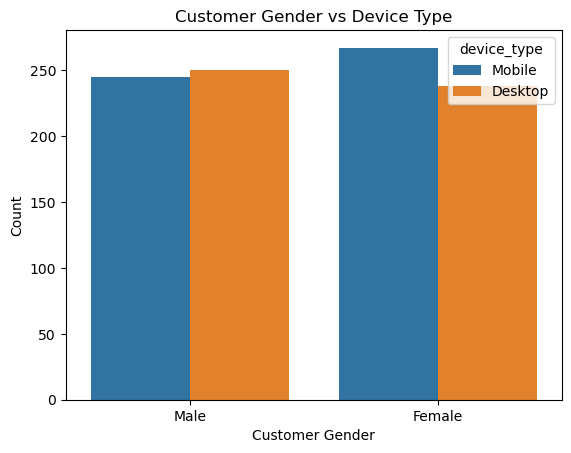

In [40]:
#Customer Gender vs Device Type vs Fraud
sns.countplot(x='customer_gender',hue='device_type',data=df)
plt.title("Customer Gender vs Device Type")
plt.xlabel("Customer Gender")
plt.ylabel("Count")

plt.show()

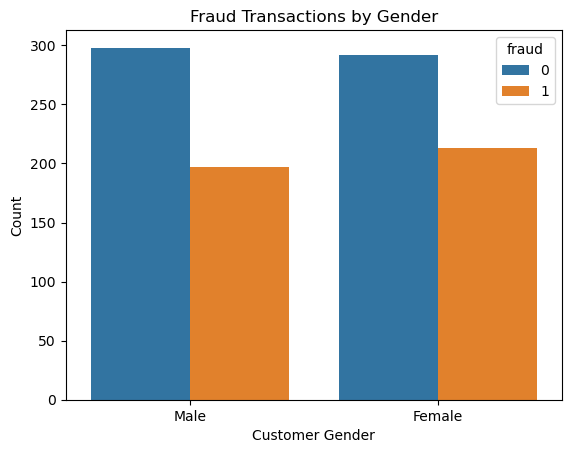

In [41]:
# Fraud Comparison by Gender and Device
sns.countplot(
    x="customer_gender",
    hue="fraud",
    data=df
)

plt.title("Fraud Transactions by Gender")
plt.xlabel("Customer Gender")
plt.ylabel("Count")

plt.show()

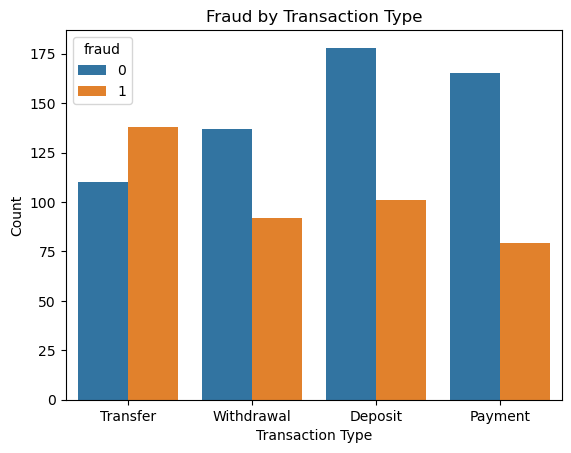

In [42]:
# Fraud by Transaction Type

# This shows which transaction type has the highest fraud cases.

sns.countplot(
    x="transaction_type",
    hue="fraud",
    data=df
)

plt.title("Fraud by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()

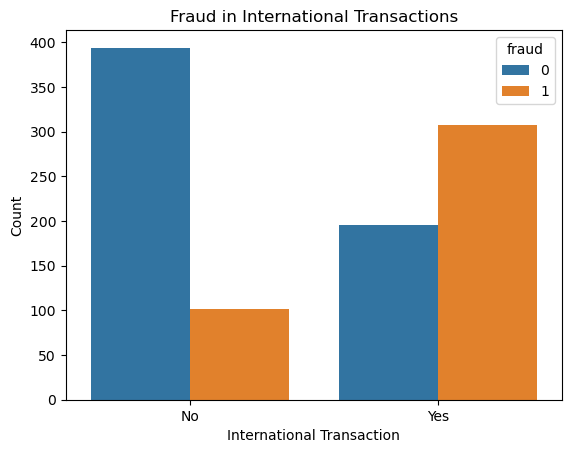

In [43]:
# Fraud by International Transactions

# This is very important in financial fraud detection.

sns.countplot(
    x="international_transaction",
    hue="fraud",
    data=df
)

plt.title("Fraud in International Transactions")
plt.xlabel("International Transaction")
plt.ylabel("Count")

plt.show()

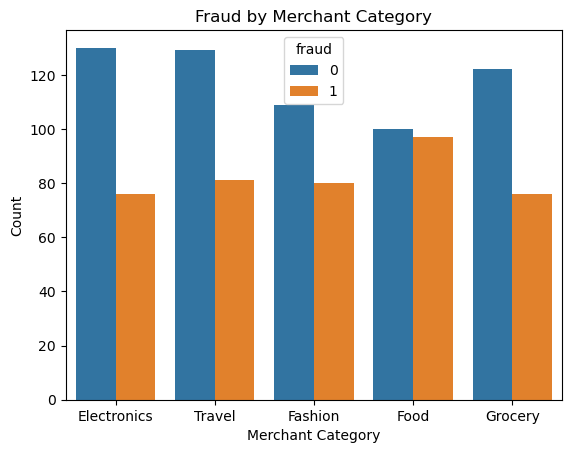

In [44]:
# Fraud by Merchant Category

# This shows which shopping categories experience more fraud.

sns.countplot(
    x="merchant_category",
    hue="fraud",
    data=df
)

plt.title("Fraud by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Count")

plt.show()

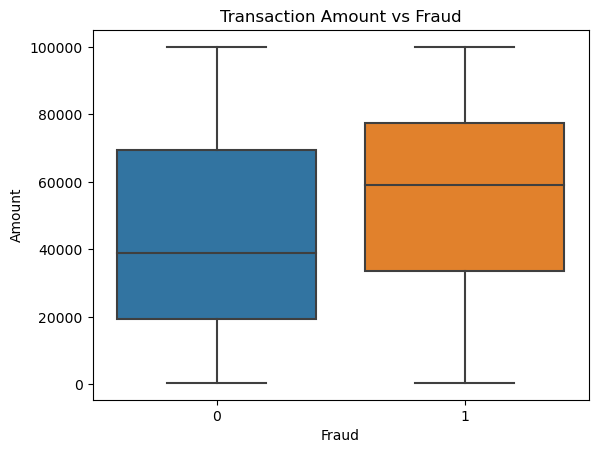

In [45]:
# Transaction Amount Distribution by Fraud

# This helps understand whether fraud transactions usually involve higher amounts.

sns.boxplot(
    x="fraud",
    y="amount",
    data=df
)

plt.title("Transaction Amount vs Fraud")
plt.xlabel("Fraud")
plt.ylabel("Amount")

plt.show()

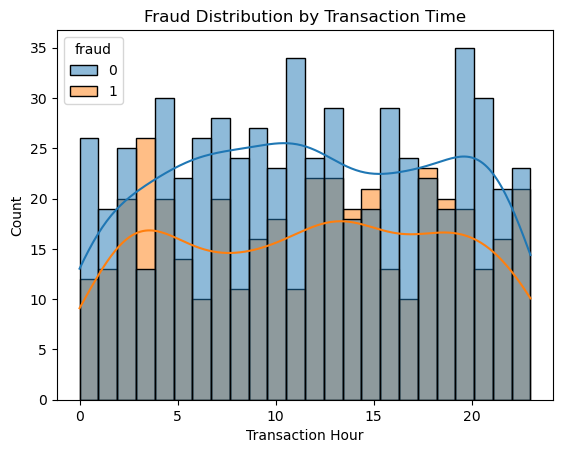

In [48]:
# Fraud by Transaction Time

# This checks whether fraud happens more during late-night hours.

sns.histplot(
    data=df,
    x="transaction_time",
    hue="fraud",
    bins=24,
    kde=True
)

plt.title("Fraud Distribution by Transaction Time")
plt.xlabel("Transaction Hour")
plt.ylabel("Count")

plt.show()

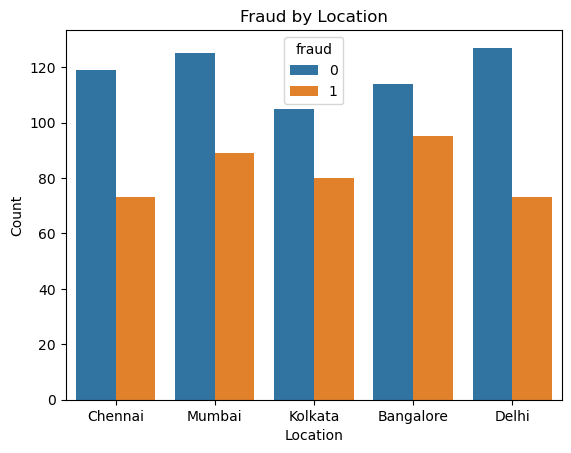

In [49]:
# Fraud by Location

# This identifies cities with higher fraud activity.

sns.countplot(
    x="location",
    hue="fraud",
    data=df
)

plt.title("Fraud by Location")
plt.xlabel("Location")
plt.ylabel("Count")


plt.show()

In [ ]:
🔍 Insights via above analysis

Example insights:
    
    
✅ Fraudulent transactions are lower compared to non fraudulent transactions
✅ International transactions have higher fraud rates
✅ Transfer transactions are more fraud-prone
✅ Food merchant category shows more fraudulent activity
✅ Fraud transactions occur more during late-night hours
✅ High transaction amounts are often linked to fraud
✅ Female gender are linked to more fraud activity.

In [ ]:
# Step 6: Convert Categorical Features into Dummy Variables

# Machine Learning models cannot understand text data directly.So we convert categorical columns into numerical columns.

In [6]:
# Convert categorical columns

df = pd.get_dummies(df, drop_first=True)

print(df.head())

   transaction_id    amount  customer_age  account_balance  transaction_time  \
0            1000   2598.57            35        115489.32                18   
1            1001  21941.93            50        282816.31                18   
2            1002  75904.86            28        173424.01                 3   
3            1003  84764.69            56        404528.50                12   
4            1004  57777.48            63         27683.07                 7   

   fraud  transaction_type_Payment  transaction_type_Transfer  \
0      1                         0                          1   
1      0                         0                          1   
2      1                         0                          1   
3      1                         0                          0   
4      1                         0                          0   

   transaction_type_Withdrawal  customer_gender_Male  device_type_Mobile  \
0                            0                     1

In [7]:
# Step 7: Feature Selection
# Independent Variables
X = df.drop(["fraud", "transaction_id"], axis=1)

In [8]:
# Dependent Variable
y = df["fraud"]

In [9]:
# Step 8: Split Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

(800, 18)


In [10]:
print(X_test.shape)

(200, 18)


In [11]:
# Step 9: Train Logistic Regression Model

logmodel = LogisticRegression()

logmodel.fit(X_train, y_train)

LogisticRegression()

In [12]:
# Step 10: Make Predictions

y_pred = logmodel.predict(X_test)

In [13]:
# Step 11: Evaluate Model Performance

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.58


In [14]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[93 25]
 [59 23]]


In [15]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.79      0.69       118
           1       0.48      0.28      0.35        82

    accuracy                           0.58       200
   macro avg       0.55      0.53      0.52       200
weighted avg       0.56      0.58      0.55       200



In [2]:
# Visualize Confusion Matrix

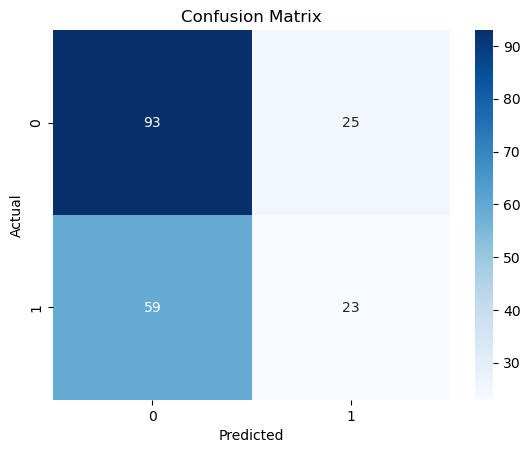

In [16]:
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [28]:
# Step 12: Predict Future Transactions

future_transaction = [[
    5000,
    35,
    25000,
    14,
    0,
    1,
    0,
    1,
    1,
    0,
    0,
    0,
    1,
    0,
    1,
    0,
    0,
    1
]]

prediction = logmodel.predict(future_transaction)
print(prediction)

if prediction[0] == 1:
    print("Fraudulent Transaction")
else:
    print("Genuine Transaction")

[0]
Genuine Transaction


C:\Users\Mohit Kedia\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
